# Q-Learning con Validación Estadística sobre Entorno Discreto

Este documento describe la implementación de un agente de aprendizaje por refuerzo tabular (Q-Learning) aplicado al entorno `Taxi-v4` de Gymnasium, cuyo espacio de estados y acciones es completamente discreto. La implementación cubre tres aspectos principales: el ciclo de entrenamiento con política epsilon-greedy, el registro visual del progreso mediante checkpoints sincronizados con una interfaz de reproducción HTML, y la validación estadística rigurosa de distintas configuraciones de hiperparámetros mediante ANOVA y corrección de Holm-Bonferroni.

## 1. Configuración del Entorno

In [5]:
import json
import io
import os
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import HTML
import base64
from pathlib import Path
import scipy.stats as stats
import statsmodels.stats.multitest as smt
from PIL import Image, ImageDraw

# Desactivar advertencias de depreciación para Taxi-v4
import warnings
warnings.filterwarnings('ignore')

Las siguientes funciones auxiliares gestionan la generación de GIFs y la anotación de frames del entorno con información de contexto (número de episodio). La función `add_text_to_frame` opera sobre arreglos NumPy convertidos temporalmente a objetos `PIL.Image`, permitiendo superponer texto sin modificar el flujo principal de renderizado.

In [6]:
def display_gif(file_path):
    gif = Path(file_path).read_bytes()
    encoded = base64.b64encode(gif).decode('ascii')
    html = f'''<img src="data:image/gif;base64,{encoded}" width="400">'''
    return HTML(html)

def save_and_show_gif(frames, filename):
    imageio.mimsave(filename, frames, fps=10, loop=0)
    return display_gif(filename)

def add_text_to_frame(frame, text):
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)
    # Agregamos texto en la esquina superior izquierda
    draw.text((10, 10), text, fill=(255, 255, 255))
    return np.array(img)

El entorno `Taxi-v4` expone un espacio de observación con **500 estados discretos** (combinaciones de posición del taxi, pasajero y destino) y **6 acciones** (cuatro desplazamientos cardinales más recoger y dejar pasajero). Este espacio compacto lo hace adecuado para Q-Learning tabular sin necesidad de aproximación de funciones.

In [7]:
env = gym.make('Taxi-v4', render_mode='rgb_array')
print(f"Espacio de Acciones: {env.action_space}")
print(f"Espacio de Estados: {env.observation_space}")

Espacio de Acciones: Discrete(6)
Espacio de Estados: Discrete(500)


## 2. Entrenamiento, Registro de Progreso y Sincronización

La Q-Table se inicializa en cero y se entrena durante **3000 episodios**, horizonte suficiente para garantizar la convergencia en este entorno. A lo largo del entrenamiento se evalúan y registran 8 checkpoints equidistantes: en cada uno se ejecuta un episodio de evaluación puro (sin exploración) y se capturan los frames resultantes. Los índices de inicio y fin de cada checkpoint (`boundaries_reales`) se exportan junto con los frames codificados en base64 al archivo `replay_data.json`, lo que permite que la interfaz HTML de reproducción opere con sincronización frame-perfect respecto a los episodios reales.

In [8]:
import io, base64, json
q_table = np.zeros([env.observation_space.n, env.action_space.n])

alpha = 0.1 # Learning rate
gamma = 0.99 # Factor de descuento
epsilon = 1.0 # Exploración inicial
epsilon_min = 0.01
epsilon_decay = 0.995

episodes = 3000
# Calculamos 8 checkpoints equitativos a lo largo del entrenamiento
checkpoints = np.linspace(0, episodes - 1, 8).astype(int)
print(f"Grabaremos el progreso en los episodios: {checkpoints}")

all_progress_frames = []
boundaries_reales = [0]
rewards_per_episode = []

for i in range(episodes):
    # --- EVALUACIÓN Y GRABACIÓN (Si estamos en un checkpoint) ---
    if i in checkpoints:
        eval_state, _ = env.reset()
        done_eval = False
        steps = 0
        while not done_eval and steps < 50:
            frame = env.render()
            frame_with_text = add_text_to_frame(frame, f"Entrenamiento: Episodio {i}")
            all_progress_frames.append(frame_with_text)
            
            # En evaluación solo explotamos (np.argmax)
            eval_action = np.argmax(q_table[eval_state])
            eval_state, _, term, trunc, _ = env.step(eval_action)
            done_eval = term or trunc
            steps += 1
        # Frame final del checkpoint
        frame = env.render()
        frame_with_text = add_text_to_frame(frame, f"Entrenamiento: Episodio {i}")
        all_progress_frames.append(frame_with_text)
        boundaries_reales.append(len(all_progress_frames))
    
    # --- ENTRENAMIENTO NORMAL ---
    state, _ = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        # Epsilon-greedy
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
            
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        
        # Ecuación de Bellman
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])
        new_value = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)
        q_table[state, action] = new_value
        
        state = next_state
        total_reward += reward
        
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

print("Entrenamiento completado.")

# Exportar datos para la interfaz HTML (evitando problemas de compresión de GIFs)
vis_dir = os.path.join(os.getcwd(), 'visualizaciones')
os.makedirs(vis_dir, exist_ok=True)
frames_b64 = []
for frame_arr in all_progress_frames:
    img = Image.fromarray(frame_arr)
    buf = io.BytesIO()
    img.save(buf, format='JPEG', quality=85)
    frames_b64.append(base64.b64encode(buf.getvalue()).decode('ascii'))
data_path = os.path.join(vis_dir, 'replay_data.json')
with open(data_path, 'w') as f:
    json.dump({'frames': frames_b64, 'boundaries': boundaries_reales}, f)
print(f"Datos para HTML exportados en: {data_path} ({len(frames_b64)} frames)")


Grabaremos el progreso en los episodios: [   0  428  856 1285 1713 2142 2570 2999]
Entrenamiento completado.
Datos para HTML exportados en: c:\Users\nelvi\OneDrive\Escritorio\6to semestre\Inteligencia Artificial\Parcial3\Reinforcement\visualizaciones\replay_data.json (295 frames)


### Análisis de Convergencia

La recompensa acumulada por episodio presenta alta varianza estocástica debido a la política epsilon-greedy y a las condiciones iniciales aleatorias del entorno. Para aislar la tendencia subyacente del aprendizaje se aplica una media móvil con ventana de 100 episodios. La estabilización de esta curva —es decir, la ausencia de pendiente sostenida— indica que la política ha convergido y que incrementos adicionales de entrenamiento no producirán mejora significativa en el valor esperado de la recompensa. Se incluye una línea de referencia en `y = 8.5` que corresponde a la recompensa óptima estimada para este entorno.

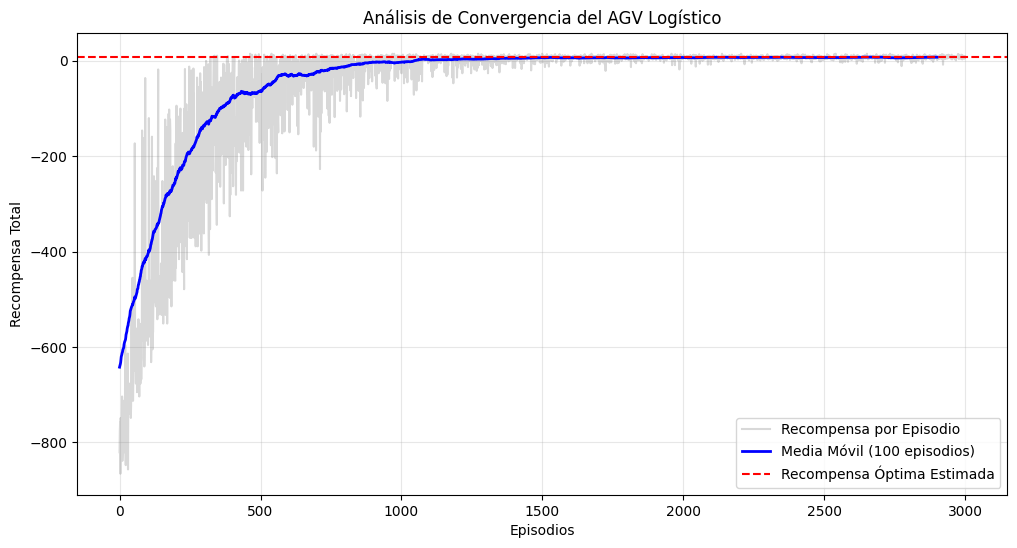

In [9]:
def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

smoothed_rewards = moving_average(rewards_per_episode, window_size=100)

plt.figure(figsize=(12, 6))
# Gráfica original con transparencia (ruido)
plt.plot(rewards_per_episode, alpha=0.3, color='gray', label='Recompensa por Episodio')
# Gráfica suavizada (convergencia)
plt.plot(smoothed_rewards, color='blue', linewidth=2, label='Media Móvil (100 episodios)')

plt.axhline(y=8.5, color='r', linestyle='--', label='Recompensa Óptima Estimada')
plt.xlabel('Episodios')
plt.ylabel('Recompensa Total')
plt.title('Análisis de Convergencia del AGV Logístico')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La secuencia de frames capturados en los checkpoints se consolida en un único GIF de progreso. Este artefacto permite comparar cualitativamente el comportamiento del agente en fases tempranas del entrenamiento (política casi aleatoria) frente a fases tardías (política estabilizada).

> **Nota:** Para actualizar la interfaz interactiva `agv_training_replay.html` con los datos del entrenamiento actual, ejecutar `scripts/update_html_frames.py` una vez finalizado el proceso. Este script procesa el archivo `replay_data.json` y reconstruye la interfaz con los frames y límites de segmento correspondientes.


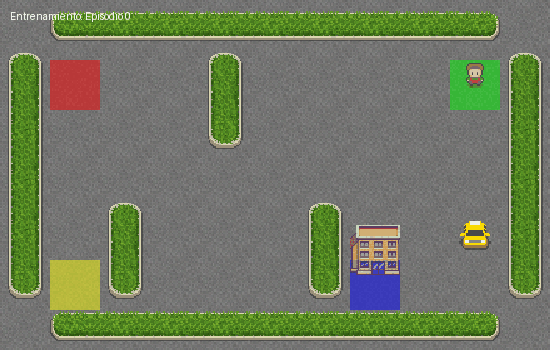

In [10]:
save_and_show_gif(all_progress_frames, 'agv_training_progress.gif')

## 3. Validación Estadística de Hiperparámetros (Multiple Testing)

La selección del learning rate $\alpha$ no puede basarse únicamente en la inspección visual de curvas de recompensa, ya que la estocasticidad del entorno introduce varianza significativa entre ejecuciones. Se evalúan tres valores de $\alpha$ \{0.1, 0.5, 0.9\} entrenando agentes independientes durante 1500 episodios cada uno, y se obtienen 100 mediciones de recompensa por evaluación. El uso de múltiples comparaciones pairwise sobre estas muestras incrementa la probabilidad de incurrir en un **Error Tipo I** (falso positivo). Para controlar esta tasa, se aplica la corrección de **Holm-Bonferroni**, que ajusta los p-valores de forma secuencial y es uniformemente más potente que la corrección de Bonferroni clásica.

In [11]:
def train_agent(alpha_val, episodes=1500):
    q_t = np.zeros([env.observation_space.n, env.action_space.n])
    eps = 1.0
    for _ in range(episodes):
        s, _ = env.reset()
        done = False
        while not done:
            a = env.action_space.sample() if np.random.uniform(0,1) < eps else np.argmax(q_t[s])
            next_s, r, term, trunc, _ = env.step(a)
            done = term or trunc
            q_t[s, a] = (1 - alpha_val) * q_t[s, a] + alpha_val * (r + 0.99 * np.max(q_t[next_s]))
            s = next_s
        eps = max(0.01, eps * 0.995)
    return q_t

def evaluate_agent(q_t, tests=100):
    results = []
    for _ in range(tests):
        s, _ = env.reset()
        done = False
        r_total = 0
        while not done:
            a = np.argmax(q_t[s])
            s, r, term, trunc, _ = env.step(a)
            done = term or trunc
            r_total += r
        results.append(r_total)
    return results

# Experimentación con 3 alfas distintos (corriendo solo 1500 episodios para ver quién aprende más rápido)
alphas = [0.1, 0.5, 0.9]
data = []
for a in alphas:
    q = train_agent(a)
    res = evaluate_agent(q)
    data.append(res)
    print(f"Alpha {a} evaluado: recompensa promedio = {np.mean(res)}")

Alpha 0.1 evaluado: recompensa promedio = -47.23
Alpha 0.5 evaluado: recompensa promedio = 7.64
Alpha 0.9 evaluado: recompensa promedio = 5.91


Se realiza primero un ANOVA de una vía para determinar si existe al menos una diferencia significativa entre los grupos. Si el resultado es significativo ($p < 0.05$), se procede con las comparaciones pairwise mediante t-tests de Welch, cuyos p-valores son ajustados con el procedimiento de Holm. Las comparaciones marcadas como `Significativo` indican que la diferencia en rendimiento entre los dos valores de $\alpha$ no es atribuible al azar con el nivel de confianza establecido.

In [12]:
# 1. ANOVA Global
f_stat, p_anova = stats.f_oneway(*data)
print(f"ANOVA p-value: {p_anova:.5f}")

# 2. Pairwise t-tests si ANOVA es significativo
if p_anova < 0.05:
    p_values = []
    comparisons = []
    for i in range(len(alphas)):
        for j in range(i+1, len(alphas)):
            _, p_val = stats.ttest_ind(data[i], data[j])
            p_values.append(p_val)
            comparisons.append(f"{alphas[i]} vs {alphas[j]}")
    
    # 3. Corrección de Holm-Bonferroni
    reject, pvals_corrected, _, _ = smt.multipletests(p_values, alpha=0.05, method='holm')
    
    print("\n--- Resultados con Corrección de Holm ---")
    for comp, p_adj, rej in zip(comparisons, pvals_corrected, reject):
        print(f"Comparación {comp}: p-adj = {p_adj:.5f} -> {'Significativo (Diferente)' if rej else 'No Significativo'}")

ANOVA p-value: 0.00000

--- Resultados con Corrección de Holm ---
Comparación 0.1 vs 0.5: p-adj = 0.00000 -> Significativo (Diferente)
Comparación 0.1 vs 0.9: p-adj = 0.00000 -> Significativo (Diferente)
Comparación 0.5 vs 0.9: p-adj = 0.41338 -> No Significativo
